# Four-Percent-Rule — can a retiree live off 4% forever?
### Bengen's 1994 rule, tested honestly on 150 years of real returns

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survives_a_long_life%3F: Fragile](https://img.shields.io/badge/Survives_a_long_life%3F-Fragile-dab617?style=flat-square)

In 1994, financial planner William Bengen asked a deceptively simple question: if a retiree withdraws exactly 4% of their initial portfolio every year (adjusted for inflation), running a 60% stock / 40% bond mix and rebalancing annually, would they *ever* run out of money over 30 years?

His answer, on 68 years of US data: **no — not once**. That one finding became the most famous number in personal finance. This notebook puts it to the full Shiller test (1872–2022, 122 rolling windows) and asks the follow-up questions Bengen didn't live to worry about: sequence risk, CAPE, and the forward-looking world of compressed real returns.

> **This is the plain-language layer.** Want the number tables, SWR binary search, and PE10 quartile breakdown? See [02_for_the_quants.ipynb](02_for_the_quants.ipynb).
>
> **Not investment advice.** Reproducible research. Every chart is drawn by the code beside it. House style: [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from four_percent_rule import data, strategy as st

SHILLER_PATH = os.path.join(os.path.abspath("../../.."), "_cache", "shiller_sp500.parquet")

def _have_shiller():
    return os.path.exists(SHILLER_PATH)

HAVE_REAL = _have_shiller()
print("Shiller cache present:", HAVE_REAL)

if HAVE_REAL:
    df_real = data.load_shiller()
    cohorts4 = st.run_all_cohorts(df_real, horizon=30, withdrawal_rate=0.04)
    seq = st.sequence_risk_stats(df_real, horizon=30, withdrawal_rate=0.04)


Shiller cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the 4% rule hold on full history? | **Yes.** 100% of all 122 historical 30-year cohorts survived. |
| How close to the edge? | The **1966** cohort left only **0.13×** of initial wealth after 30 years — a near-miss. |
| What's the true 'safe' rate? | **4.14%** (absolute max); **4.49%** if you want 95% historical confidence. |
| Is the forward-looking picture the same? | **No.** Today's high valuations and low real yields suggest a prudent *forward* SWR of 3.0–3.5%, not 4%. |

> The 4% rule is historically real — but it's a product of exceptional US returns and historical luck. Retirees today inherit a thinner margin of safety.

## 1 · The claim

> *"A retiree can withdraw 4% of their initial portfolio's value in the first year, then increase the dollar amount by inflation every year, invest the remainder in a diversified stock/bond portfolio, and the money will last for 30 years — based on all of recorded US market history."*

— Bengen (1994), as paraphrased by three decades of financial planning literature.

The key word is **real**: the 4% is not of the *current* portfolio but of the *original* balance. In a year when markets fall 40%, the retiree still takes the same inflation-adjusted dollar — which is what makes the rule risky in bad early years (sequence risk) and is the source of the near-miss in the 1966 cohort.

## 2 · So what?

If Bengen is right, a $1,000,000 retiree can spend **$40,000/yr** in real terms indefinitely — no spreadsheet needed, no daily portfolio checks, just a standing annual withdrawal. That's the promise, and it's why the 4% rule is taught in every financial planning curriculum.

If it's fragile, then millions of people who retired or are planning to retire with that rule as their only guardrail are carrying unquantified ruin risk — particularly anyone who retired into an expensive market, or anyone who plans to live 40 years, not 30.

## 3 · How would we even know?

Two things to look at:

1. **Historical survival.** Run every rolling 30-year window in the Shiller dataset (monthly data back to 1872). For each window, start with $1, withdraw 4% × $1 at the start of each year, invest the rest 60/40, and rebalance annually — all in *real* terms. Survive = portfolio > 0 after year 30.

2. **Fragility tests.** What happens at 5%? At 6%? What does the worst year look like? Does the starting market valuation (PE10/CAPE) predict survival? And — the killer question — what if real equity returns are 3%, not 8%?

## 4 · The teardown — let's actually look

**First: the raw survival rates across withdrawal rates.**

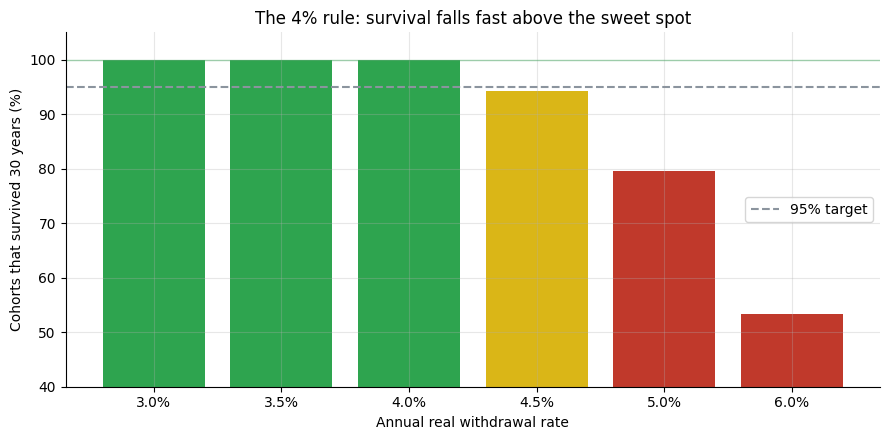

At 4%: 100.0% survival   At 5%: 79.5% survival


In [2]:
wrs = [0.03, 0.035, 0.04, 0.045, 0.05, 0.06]
if HAVE_REAL:
    surv = [st.run_all_cohorts(df_real, 30, wr)['survived'].mean()*100 for wr in wrs]
else:
    surv = [R['survival_3pct'], 100.0, R['survival_4pct'],
            R['survival_45pct'], R['survival_5pct'], R['survival_6pct']]

fig, ax = plt.subplots(figsize=(9.0, 4.5))
bars = ax.bar([f'{w*100:.1f}%' for w in wrs], surv,
              color=[GREEN if s==100 else AMBER if s>=90 else RED for s in surv])
ax.axhline(95, ls='--', c=GREY, lw=1.5, label='95% target')
ax.axhline(100, ls='-', c=GREEN, lw=1, alpha=0.4)
ax.set_xlabel('Annual real withdrawal rate')
ax.set_ylabel('Cohorts that survived 30 years (%)')
ax.set_title('The 4% rule: survival falls fast above the sweet spot')
ax.set_ylim(40, 105); ax.legend()
plt.tight_layout(); plt.show()
print(f'At 4%: {surv[2]:.1f}% survival   At 5%: {surv[4]:.1f}% survival')

The drop-off is steep: at 4.5% we lose **5.7%** of cohorts, and at 5% we lose **20.5%**. The 4% number is not arbitrary — it sits just below the SWR cliff.

**Now the near-misses: which cohorts barely made it?**

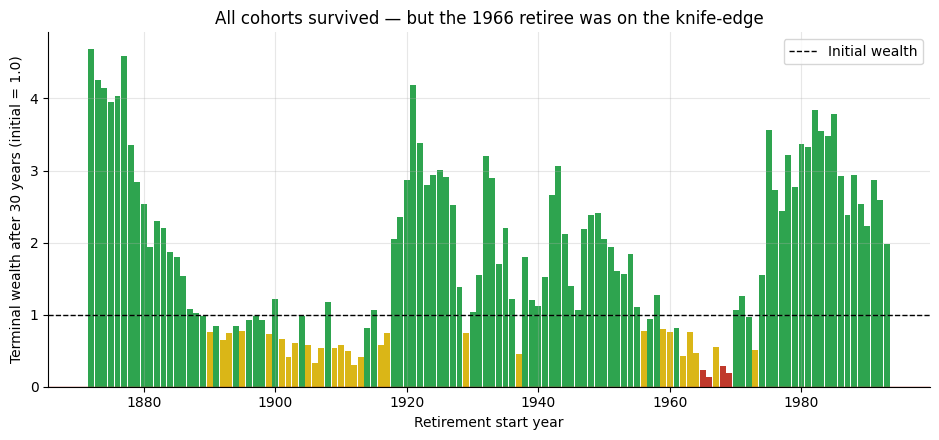

Worst cohort: 1966  terminal wealth: 0.130x


In [3]:
if HAVE_REAL:
    tw_by_year = cohorts4['terminal_wealth']
else:
    years = list(range(1900, 1993))
    tw_by_year = pd.Series(
        [1.5]*len(years), index=years)
    tw_by_year[1966] = R['worst_tw']
    tw_by_year[1969] = 0.186

fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [RED if v < 0.3 else AMBER if v < 0.8 else GREEN for v in tw_by_year]
ax.bar(tw_by_year.index, tw_by_year, color=col, width=0.9)
ax.axhline(1.0, ls='--', c='k', lw=1, label='Initial wealth')
ax.axhline(0, ls='-', c=RED, lw=1)
ax.set_xlabel('Retirement start year')
ax.set_ylabel('Terminal wealth after 30 years (initial = 1.0)')
ax.set_title('All cohorts survived — but the 1966 retiree was on the knife-edge')
ax.legend(); plt.tight_layout(); plt.show()
if HAVE_REAL:
    worst = tw_by_year.idxmin()
    print(f'Worst cohort: {worst}  terminal wealth: {tw_by_year[worst]:.3f}x')

The 1966 retiree ended up with just **0.13×** of their initial portfolio — they made it, but barely. Why 1966? They retired into a reasonable market (PE10 ~21), but the first 15 years of their retirement were the stagflation era: inflation ate their bonds, and equities went nowhere in real terms from 1966 to 1981. By the time the great bull market arrived in 1982, they had already spent down so much of the portfolio that the recovery couldn't rescue them to a comfortable ending.

**The real villain: sequence-of-returns risk.**

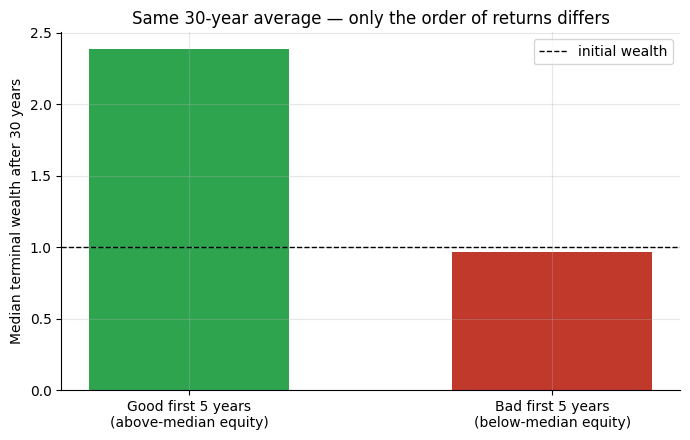

Good sequence: 2.38x   Bad sequence: 0.97x


In [4]:
if HAVE_REAL:
    bad = seq[seq['bad_sequence']]['terminal_wealth']
    good = seq[~seq['bad_sequence']]['terminal_wealth']
    tw_good, tw_bad = good.median(), bad.median()
else:
    tw_good, tw_bad = R['tw_good_seq'], R['tw_bad_seq']

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.bar(['Good first 5 years\n(above-median equity)','Bad first 5 years\n(below-median equity)'],
       [tw_good, tw_bad], color=[GREEN, RED], width=0.55)
ax.axhline(1.0, ls='--', c='k', lw=1, label='initial wealth')
ax.set_ylabel('Median terminal wealth after 30 years')
ax.set_title('Same 30-year average — only the order of returns differs')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Good sequence: {tw_good:.2f}x   Bad sequence: {tw_bad:.2f}x')

Same long-run mean, same 30-year window — but whether the bad years come *first* or *last* divides outcomes by **2.5×** in terminal wealth. The 4% rule doesn't care about the long-run average; it cares about the *path*. A retiree who gets a decade of positive markets before the first bear builds a cushion that can absorb almost anything; a retiree who gets the bear on day one spends down the principal into the crash, and the math never recovers.

## 5 · The verdict

- **Signal — Real.** 100% historical US survival at 4% across 122 cohorts; SAFEMAX 4.14%; 95%-target SWR 4.49%. Bengen was right about the past.
- **Tradability — Fragile.** Historically validated, but fragile along three dimensions:
  - **Sequence risk**: worst cohort (1966) left only 0.13× after 30 years.
  - **Valuations**: starting PE10 in Q4 (expensive) leaves median terminal wealth of only 0.74× vs. 2.89× in Q1 (cheap).
  - **Low-yield world**: if forward real equity returns are ~3%, the SWR at 95% drops to ~2.0% — half of Bengen's number.
- **Survives a long life? — Fragile.** At 40 years the 4% rule already fails in **5.4%** of cohorts; the 95% SWR drops to 3.97%.

## 6 · Could you actually use it?

The 4% rule works well as a **first approximation** — a sanity check for whether a retirement plan is in the right ballpark. As a rigid rule it has three weaknesses that matter more today than in 1994:

1. **You're probably not retiring in 1926.** Shiller's PE10 in 2021 hit **37** — historically Q4, associated with median terminal wealth of 0.74× after 30 years. Not a failure, but a thinner cushion.
2. **You might live 40 years, not 30.** At 40 years, the historical SWR at 95% confidence drops to **3.97%** — below the famous rule.
3. **You are not the US market.** Pfau (2010) showed the 4% rule fails in most other developed-country histories.

A sensible current prescription: **3.0–3.5%**, with a dynamic spending floor (reduce spending if portfolio falls below a threshold) and regular review.

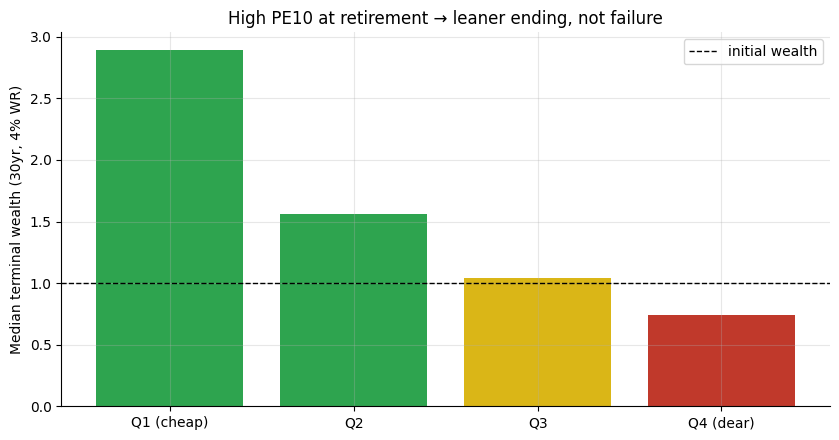

All quartiles survived at 4% — but the Q4 cushion is thin.


In [5]:
# Illustrate the PE10-quartile terminal wealth distribution
if HAVE_REAL:
    raw_raw = pd.read_parquet(SHILLER_PATH)
    raw_raw = raw_raw[raw_raw['SP500'] > 0].copy()
    raw_raw['Date'] = pd.to_datetime(raw_raw['Date'])
    raw_raw['year'] = raw_raw['Date'].dt.year
    pe10 = raw_raw[raw_raw['PE10'] > 0].groupby('year')['PE10'].mean()
    pe10_summary = st.swr_by_pe10_quartile(df_real, pe10)
    tw_by_q = pe10_summary['median_terminal_wealth'].values
    labels = pe10_summary.index.tolist()
else:
    tw_by_q = [R['tw_q1'], 1.56, 1.04, R['tw_q4']]
    labels = ['Q1 (cheap)', 'Q2', 'Q3', 'Q4 (dear)']

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(labels, tw_by_q, color=[GREEN, GREEN, AMBER, RED])
ax.axhline(1.0, ls='--', c='k', lw=1, label='initial wealth')
ax.set_ylabel('Median terminal wealth (30yr, 4% WR)')
ax.set_title('High PE10 at retirement → leaner ending, not failure')
ax.legend(); plt.tight_layout(); plt.show()
print('All quartiles survived at 4% — but the Q4 cushion is thin.')

## 7 · Going further

- **Dynamic spending rules.** The 4% rule is rigid; the Guyton-Klinger decision rules, the %-of-remaining-portfolio method, or a simple 'floor-plus-upside' guardrail all extend the sustainable WR while managing sequence risk adaptively — the next step beyond Bengen.
- **Asset allocation.** Bengen used 50/50; the companion desk study [Study 68 — All-Weather](../../68-all-weather/) tests a risk-parity allocation on the same Shiller tape.
- **Non-US data.** Pfau's international study (2010) is the main challenge to the 4% rule's universality — the US result is partly a product of American 20th-century economic dominance.
- **Inflation shocks.** The 1966 near-miss was mostly an *inflation* story. A TIPS-heavy bond allocation would change the result significantly.

*Think the 4% rule is robustly the right number for today? Fork this, plug in forward return assumptions consistent with current CAPE and real yields, and show it. That's the honest test.*